# Empirical delay propagation on the Zürich–Chur railway corridor

An exploratory analysis of how arrival delays propagate along a Swiss main-line
corridor, using SBB's public operational data (`ist-daten-v2`) for 10 September 2026.

For each of the eight adjacent-station segments along the corridor, the outgoing
arrival delay is regressed on the incoming arrival delay via OLS. The slope β
is the propagation coefficient: β = 1 means delay carries forward untouched,
β = 0 means it is fully absorbed. The main finding is that β varies from 0.14
to 0.96 across the corridor, with absorption concentrated near the major
stations at Zürich HB and Chur.

**Data source:** [opentransportdata.swiss](https://data.opentransportdata.swiss/en/dataset/ist-daten-v2),
Business Office SKI (CC-BY-4.0).
See `README.md` for context, methodology, and limitations.

**Notebook structure**

1. Data loading and initial inspection
2. Filtering to trains, real-time telemetry, and the Zürich–Chur corridor
3. Delay computation
4. Distribution overview
5. Per-segment propagation regressions (β and α)
6. Residual diagnostics

##1. Data loading and initial inspection

In [ ]:
# to get the file directly from transportdata
url = "https://data.opentransportdata.swiss/dataset/febff1f3-ee85-470a-9487-2d07f93457c1/resource/4ac5bcf3-8dbc-4b12-b700-a6dac7dd7397/download/2026-09-10_istdaten.csv"
!wget -q "$url" -O ist_daten_2026_09_10.csv
!ls -lh ist_daten_2026_09_10.csv

-rw-r--r-- 1 root root 614M Sep 11 03:11 ist_daten_2026_09_10.csv


In [ ]:
csv_path = "ist_daten_2026_09_10.csv"

# we take a look at few lines to confirm delimiter and encoding
with open(csv_path, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i < 3:
            print(repr(line))
        else:
            break

'BETRIEBSTAG;FAHRT_BEZEICHNER;BETREIBER_ID;BETREIBER_ABK;BETREIBER_NAME;PRODUKT_ID;LINIEN_ID;LINIEN_TEXT;UMLAUF_ID;VERKEHRSMITTEL_TEXT;ZUSATZFAHRT_TF;FAELLT_AUS_TF;BPUIC;HALTESTELLEN_NAME;ANKUNFTSZEIT;AN_PROGNOSE;AN_PROGNOSE_STATUS;ABFAHRTSZEIT;AB_PROGNOSE;AB_PROGNOSE_STATUS;DURCHFAHRT_TF;SLOID\n'
'10.09.2026;55:55____:19912:000;55:55____;MÁV-START;Magyar Államvasutak START Zrt.;Zug;19912;RJX;;RJX;false;false;5510017;Budapest-Keleti;;;;10.09.2026 06:30;;UNBEKANNT;false;\n'
'10.09.2026;55:55____:19912:000;55:55____;MÁV-START;Magyar Államvasutak START Zrt.;Zug;19912;RJX;;RJX;false;false;5501024;Kelenföld;10.09.2026 06:47;;UNBEKANNT;10.09.2026 06:50;;UNBEKANNT;false;\n'


In [ ]:
!wc -l ist_daten_2026_09_10.csv

2528137 ist_daten_2026_09_10.csv


This tells us the file is complete and matches the web preview

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# nicer default plot style
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 200
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 200)

In [ ]:
# columns we actually need for delay-propagation analysis
usecols = [
    'BETRIEBSTAG', 'FAHRT_BEZEICHNER',
    'PRODUKT_ID', 'LINIEN_TEXT', 'VERKEHRSMITTEL_TEXT',
    'FAELLT_AUS_TF', 'DURCHFAHRT_TF',
    'BPUIC', 'HALTESTELLEN_NAME',
    'ANKUNFTSZEIT', 'AN_PROGNOSE', 'AN_PROGNOSE_STATUS',
    'ABFAHRTSZEIT', 'AB_PROGNOSE', 'AB_PROGNOSE_STATUS',
]

# dtype hints save memory and speed up the read
dtypes = {
    'BETRIEBSTAG': 'string',
    'FAHRT_BEZEICHNER': 'string',
    'PRODUKT_ID': 'category',
    'LINIEN_TEXT': 'string',
    'VERKEHRSMITTEL_TEXT': 'category',
    'BPUIC': 'string',        # string, not int — some rows have long SLOID-style values
    'HALTESTELLEN_NAME': 'string',
    'AN_PROGNOSE_STATUS': 'category',
    'AB_PROGNOSE_STATUS': 'category',
}

df = pd.read_csv(
    csv_path,
    sep=';',
    encoding='utf-8',
    usecols=usecols,
    dtype=dtypes,
    low_memory=False,
)

print(f"Loaded: {len(df):,} rows")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"Columns: {list(df.columns)}")
df.head(3)

Loaded: 2,528,136 rows
Memory: 1482.8 MB
Columns: ['BETRIEBSTAG', 'FAHRT_BEZEICHNER', 'PRODUKT_ID', 'LINIEN_TEXT', 'VERKEHRSMITTEL_TEXT', 'FAELLT_AUS_TF', 'BPUIC', 'HALTESTELLEN_NAME', 'ANKUNFTSZEIT', 'AN_PROGNOSE', 'AN_PROGNOSE_STATUS', 'ABFAHRTSZEIT', 'AB_PROGNOSE', 'AB_PROGNOSE_STATUS', 'DURCHFAHRT_TF']


,BETRIEBSTAG,FAHRT_BEZEICHNER,PRODUKT_ID,LINIEN_TEXT,VERKEHRSMITTEL_TEXT,FAELLT_AUS_TF,BPUIC,HALTESTELLEN_NAME,ANKUNFTSZEIT,AN_PROGNOSE,AN_PROGNOSE_STATUS,ABFAHRTSZEIT,AB_PROGNOSE,AB_PROGNOSE_STATUS,DURCHFAHRT_TF
0,10.09.2026,55:55____:19912:000,Zug,RJX,RJX,False,5510017,Budapest-Keleti,NaN,NaN,NaN,10.09.2026 06:30,NaN,UNBEKANNT,False
1,10.09.2026,55:55____:19912:000,Zug,RJX,RJX,False,5501024,Kelenföld,10.09.2026 06:47,NaN,UNBEKANNT,10.09.2026 06:50,NaN,UNBEKANNT,False
2,10.09.2026,55:55____:19912:000,Zug,RJX,RJX,False,5501131,Tatabánya,10.09.2026 07:25,NaN,UNBEKANNT,10.09.2026 07:26,NaN,UNBEKANNT,False


And some sanity checks:

In [ ]:
print("=== Product distribution ===")
print(df['PRODUKT_ID'].value_counts(dropna=False))

print("\n=== Prognose status distribution (arrival) ===")
print(df['AN_PROGNOSE_STATUS'].value_counts(dropna=False))

print("\n=== Prognose status distribution (departure) ===")
print(df['AB_PROGNOSE_STATUS'].value_counts(dropna=False))

print("\n=== Cancelled trips ===")
print(df['FAELLT_AUS_TF'].value_counts(dropna=False))

print("\n=== Pass-through (no stop) ===")
print(df['DURCHFAHRT_TF'].value_counts(dropna=False))

print("\n=== Top 15 service categories ===")
print(df['VERKEHRSMITTEL_TEXT'].value_counts().head(15))

=== Product distribution ===
PRODUKT_ID
Bus            2038405
Tram            229798
Zug             181226
BUS              71255
Metro             4864
Zahnradbahn       1804
Schiff             720
NaN                 64
Name: count, dtype: int64

=== Prognose status distribution (arrival) ===
AN_PROGNOSE_STATUS
REAL          2216079
NaN            153341
GESCHAETZT      76180
PROGNOSE        66567
UNBEKANNT       15969
Name: count, dtype: int64

=== Prognose status distribution (departure) ===
AB_PROGNOSE_STATUS
REAL          2211879
NaN            153407
GESCHAETZT      78974
PROGNOSE        67343
UNBEKANNT       16533
Name: count, dtype: int64

=== Cancelled trips ===
FAELLT_AUS_TF
False    2511178
True       16958
Name: count, dtype: int64

=== Pass-through (no stop) ===
DURCHFAHRT_TF
False    2528093
True          43
Name: count, dtype: int64

=== Top 15 service categories ===
VERKEHRSMITTEL_TEXT
B      2107494
T       229798
S       112603
R        36398
RE       10957
IR     

## 2. Filtering to trains, real-time telemetry, and the Zürich–Chur corridor

let's do the cheap filters that apply universally

In [ ]:
# Step 1: restrict to trains, non-cancelled, non-passthrough
trains = df[
    (df['PRODUKT_ID'] == 'Zug') &
    (df['FAELLT_AUS_TF'] == False) &
    (df['DURCHFAHRT_TF'] == False)
].copy()

print(f"After train + not-cancelled + not-passthrough: {len(trains):,} rows")

# Step 2: check what fraction of TRAIN rows have REAL telemetry
print("\nTrain arrival status:")
print(trains['AN_PROGNOSE_STATUS'].value_counts(dropna=False))
print("\nTrain departure status:")
print(trains['AB_PROGNOSE_STATUS'].value_counts(dropna=False))

# Step 3: check the service-category distribution among trains
print("\nTrain service categories (top 15):")
print(trains['VERKEHRSMITTEL_TEXT'].value_counts().head(15))

After train + not-cancelled + not-passthrough: 177,328 rows

Train arrival status:
AN_PROGNOSE_STATUS
REAL          141856
NaN            15454
PROGNOSE       13080
UNBEKANNT       6938
GESCHAETZT         0
Name: count, dtype: int64

Train departure status:
AB_PROGNOSE_STATUS
REAL          142349
NaN            15312
PROGNOSE       12667
UNBEKANNT       7000
GESCHAETZT         0
Name: count, dtype: int64

Train service categories (top 15):
VERKEHRSMITTEL_TEXT
S      110059
R       35892
RE      10881
IR       8071
TER      3624
IC       3111
RB       1626
PE       1326
ICE       797
EC        704
RJX       433
TGV       376
NJ        158
ATZ       120
RJ         39
Name: count, dtype: int64


In [ ]:
# Look up the actual BPUIC codes for these station names.
# We use flexible substring matching because names can have small variations.
corridor_names = [
    'Zürich HB', 'Thalwil', 'Pfäffikon SZ', 'Ziegelbrücke',
    'Sargans', 'Bad Ragaz', 'Maienfeld', 'Landquart', 'Chur',
]

# For each candidate name, show which BPUIC codes appear in the data
for name in corridor_names:
    matches = trains[trains['HALTESTELLEN_NAME'].str.contains(
        name, case=False, na=False, regex=False
    )][['HALTESTELLEN_NAME', 'BPUIC']].drop_duplicates()

    print(f"\n=== {name} ===")
    print(matches.head(5).to_string(index=False))


=== Zürich HB ===
HALTESTELLEN_NAME   BPUIC
        Zürich HB 8503000

=== Thalwil ===
HALTESTELLEN_NAME   BPUIC
          Thalwil 8503202

=== Pfäffikon SZ ===
HALTESTELLEN_NAME   BPUIC
     Pfäffikon SZ 8503209

=== Ziegelbrücke ===
HALTESTELLEN_NAME   BPUIC
     Ziegelbrücke 8503225

=== Sargans ===
HALTESTELLEN_NAME   BPUIC
          Sargans 8509411

=== Bad Ragaz ===
HALTESTELLEN_NAME   BPUIC
        Bad Ragaz 8509004

=== Maienfeld ===
HALTESTELLEN_NAME   BPUIC
        Maienfeld 8509003

=== Landquart ===
HALTESTELLEN_NAME   BPUIC
        Landquart 8509002
   Landquart Ried 8509056

=== Chur ===
HALTESTELLEN_NAME   BPUIC
             Chur 8509000
        Chur West 8509050
    Chur Altstadt 8509150
   Chur Wiesental 8509006


In [ ]:
# The canonical corridor (in geographical order Zurich → Chur)
corridor_ids = [
    '8503000',  # Zürich HB
    '8503202',  # Thalwil
    '8503209',  # Pfäffikon SZ
    '8503225',  # Ziegelbrücke
    '8509411',  # Sargans
    '8509004',  # Bad Ragaz
    '8509003',  # Maienfeld
    '8509002',  # Landquart
    '8509000',  # Chur
]

# ordering for later
corridor_order = {bpuic: i for i, bpuic in enumerate(corridor_ids)}
corridor_names_ordered = [
    'Zürich HB', 'Thalwil', 'Pfäffikon SZ', 'Ziegelbrücke',
    'Sargans', 'Bad Ragaz', 'Maienfeld', 'Landquart', 'Chur'
]

# Step 1: restrict to corridor stops with REAL arrival telemetry
mask = (
    trains['BPUIC'].isin(corridor_ids) &
    (trains['AN_PROGNOSE_STATUS'] == 'REAL')
)
corr = trains.loc[mask].copy()
print(f"Corridor rows with REAL arrival: {len(corr):,}")

# Step 2: parse timestamps
corr['scheduled_arr'] = pd.to_datetime(
    corr['ANKUNFTSZEIT'], format='%d.%m.%Y %H:%M', errors='coerce'
)
corr['actual_arr'] = pd.to_datetime(
    corr['AN_PROGNOSE'], format='%d.%m.%Y %H:%M', errors='coerce'
)

# Step 3: compute arrival delay in minutes (positive = late)
corr['arr_delay_min'] = (
    corr['actual_arr'] - corr['scheduled_arr']
).dt.total_seconds() / 60.0

# Step 4: add the corridor position index for later ordering
corr['corridor_pos'] = corr['BPUIC'].map(corridor_order)

# how does the delay distribution look?
print("\n=== Arrival delay distribution (minutes) ===")
print(corr['arr_delay_min'].describe(percentiles=[.05, .25, .5, .75, .9, .95, .99]))

# quick station-level summary
print("\n=== Rows per corridor station ===")
station_counts = (
    corr.groupby(['corridor_pos', 'HALTESTELLEN_NAME'])
        .size()
        .reset_index(name='n_arrivals')
        .sort_values('corridor_pos')
)
print(station_counts.to_string(index=False))

Corridor rows with REAL arrival: 3,327

=== Arrival delay distribution (minutes) ===
count    0.0
mean     NaN
std      NaN
min      NaN
5%       NaN
25%      NaN
50%      NaN
75%      NaN
90%      NaN
95%      NaN
99%      NaN
max      NaN
Name: arr_delay_min, dtype: float64

=== Rows per corridor station ===
 corridor_pos HALTESTELLEN_NAME  n_arrivals
            0         Zürich HB        1546
            1           Thalwil         293
            2      Pfäffikon SZ         275
            3      Ziegelbrücke         196
            4           Sargans         203
            5         Bad Ragaz         149
            6         Maienfeld         148
            7         Landquart         276
            8              Chur         241


perhaps a time format mismatch

In [ ]:
# What do the timestamp columns actually look like in the corridor subset?
print("=== ANKUNFTSZEIT samples ===")
print(corr['ANKUNFTSZEIT'].dropna().head(10).tolist())

print("\n=== AN_PROGNOSE samples ===")
print(corr['AN_PROGNOSE'].dropna().head(10).tolist())

print("\n=== dtype check ===")
print(f"ANKUNFTSZEIT dtype: {corr['ANKUNFTSZEIT'].dtype}")
print(f"AN_PROGNOSE dtype: {corr['AN_PROGNOSE'].dtype}")

print("\n=== null counts ===")
print(f"ANKUNFTSZEIT nulls: {corr['ANKUNFTSZEIT'].isna().sum()} / {len(corr)}")
print(f"AN_PROGNOSE nulls: {corr['AN_PROGNOSE'].isna().sum()} / {len(corr)}")

=== ANKUNFTSZEIT samples ===
['10.09.2026 10:27', '10.09.2026 16:00', '10.09.2026 17:02', '10.09.2026 07:00', '10.09.2026 21:17', '10.09.2026 21:27', '10.09.2026 22:22', '10.09.2026 06:23', '10.09.2026 07:23', '10.09.2026 08:23']

=== AN_PROGNOSE samples ===
['10.09.2026 10:55:33', '10.09.2026 16:30:16', '10.09.2026 17:36:16', '10.09.2026 07:00:32', '10.09.2026 21:16:24', '10.09.2026 21:25:47', '10.09.2026 22:22:16', '10.09.2026 06:30:42', '10.09.2026 07:23:59', '10.09.2026 08:22:49']

=== dtype check ===
ANKUNFTSZEIT dtype: object
AN_PROGNOSE dtype: object

=== null counts ===
ANKUNFTSZEIT nulls: 0 / 3327
AN_PROGNOSE nulls: 0 / 3327


So the scheduled and actual times use different precisions.

## 3. Delay computation

In [ ]:
# Re-parse with the correct format for each column
corr['scheduled_arr'] = pd.to_datetime(
    corr['ANKUNFTSZEIT'], format='%d.%m.%Y %H:%M', errors='coerce'
)
corr['actual_arr'] = pd.to_datetime(
    corr['AN_PROGNOSE'], format='%d.%m.%Y %H:%M:%S', errors='coerce'
)

# Recompute arrival delay in minutes (positive = late)
corr['arr_delay_min'] = (
    corr['actual_arr'] - corr['scheduled_arr']
).dt.total_seconds() / 60.0

# Sanity check: any parse failures now?
print(f"Scheduled arrival NaT: {corr['scheduled_arr'].isna().sum()} / {len(corr)}")
print(f"Actual arrival NaT:    {corr['actual_arr'].isna().sum()} / {len(corr)}")
print(f"Delay NaN:             {corr['arr_delay_min'].isna().sum()} / {len(corr)}")

print("\n=== Arrival delay distribution (minutes) ===")
print(corr['arr_delay_min'].describe(percentiles=[.05, .25, .5, .75, .9, .95, .99]).round(2))

Scheduled arrival NaT: 0 / 3327
Actual arrival NaT:    0 / 3327
Delay NaN:             0 / 3327

=== Arrival delay distribution (minutes) ===
count    3327.00
mean        0.90
std         2.08
min        -2.72
5%         -0.88
25%        -0.07
50%         0.52
75%         1.35
90%         2.47
95%         3.44
99%         8.53
max        34.27
Name: arr_delay_min, dtype: float64


In [ ]:
# Build train × station pivot: rows = trains, columns = corridor stations, values = arr_delay_min
# Use FAHRT_BEZEICHNER as the train identifier
delay_matrix = (
    corr
    .pivot_table(
        index='FAHRT_BEZEICHNER',
        columns='corridor_pos',
        values='arr_delay_min',
        aggfunc='first',   # if any train arrives twice at same station, take first
    )
    .sort_index(axis=1)
)

# Rename columns from corridor_pos indices to station names
delay_matrix.columns = [corridor_names_ordered[i] for i in delay_matrix.columns]
print(f"Train × station delay matrix: {delay_matrix.shape}")
print(delay_matrix.head())

# For each adjacent segment, count how many trains visit BOTH endpoints
print("\n=== Trains visiting both endpoints of each segment ===")
segments = list(zip(corridor_names_ordered[:-1], corridor_names_ordered[1:]))
for a, b in segments:
    n_both = delay_matrix[[a, b]].dropna().shape[0]
    print(f"  {a:16s} → {b:16s}  n = {n_both}")

Train × station delay matrix: (2184, 9)
                            Zürich HB  Thalwil  Pfäffikon SZ  Ziegelbrücke    Sargans  Bad Ragaz  Maienfeld  Landquart  Chur
FAHRT_BEZEICHNER                                                                                                            
ch:1:sjyid:100001:10-001    28.550000      NaN           NaN           NaN        NaN        NaN        NaN        NaN   NaN
ch:1:sjyid:100001:105-002   30.266667      NaN           NaN           NaN  34.266667        NaN        NaN        NaN   NaN
ch:1:sjyid:100001:1057-001   0.533333      NaN           NaN           NaN        NaN        NaN        NaN        NaN   NaN
ch:1:sjyid:100001:1058-002   0.266667      NaN           NaN           NaN  -1.216667        NaN        NaN       -0.6   NaN
ch:1:sjyid:100001:1083-002   7.700000      NaN           NaN           NaN        NaN        NaN        NaN        NaN   NaN

=== Trains visiting both endpoints of each segment ===
  Zürich HB        → Thalwil 

So 2,184 unique trains visit at least one corridor station

In [ ]:
from scipy import stats

# Threshold for the "large delay" regime
LARGE_DELAY_THRESHOLD = 3.0  # minutes; ~90th percentile

def fit_segment(x, y):
    """OLS regression of y on x. Returns dict with slope, intercept, R^2, n, std_err."""
    if len(x) < 5:
        return None
    result = stats.linregress(x, y)
    return {
        'n': len(x),
        'beta': result.slope,
        'alpha': result.intercept,
        'r2': result.rvalue ** 2,
        'p': result.pvalue,
        'se_beta': result.stderr,
    }

rows = []
for k in range(len(corridor_names_ordered) - 1):
    a = corridor_names_ordered[k]
    b = corridor_names_ordered[k + 1]

    pair = delay_matrix[[a, b]].dropna()
    if len(pair) < 5:
        continue

    # All trains
    all_fit = fit_segment(pair[a].values, pair[b].values)
    # Trains with large incoming delay
    large = pair[pair[a] > LARGE_DELAY_THRESHOLD]
    large_fit = fit_segment(large[a].values, large[b].values) if len(large) >= 5 else None
    # Trains with small incoming delay (for the contrast plot)
    small = pair[pair[a] <= LARGE_DELAY_THRESHOLD]
    small_fit = fit_segment(small[a].values, small[b].values) if len(small) >= 5 else None

    rows.append({
        'segment': f"{a} → {b}",
        'k': k,
        'n_all':   all_fit['n'],
        'beta_all': all_fit['beta'],
        'alpha_all': all_fit['alpha'],
        'r2_all':  all_fit['r2'],
        'n_small':  small_fit['n'] if small_fit else 0,
        'beta_small': small_fit['beta'] if small_fit else np.nan,
        'n_large':  large_fit['n'] if large_fit else 0,
        'beta_large': large_fit['beta'] if large_fit else np.nan,
    })

results = pd.DataFrame(rows)
print(results.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

                    segment  k  n_all  beta_all  alpha_all  r2_all  n_small  beta_small  n_large  beta_large
        Zürich HB → Thalwil  0    272     0.464      0.738   0.269      250       0.380       22      -0.102
     Thalwil → Pfäffikon SZ  1     94     0.506      0.061   0.347       84       0.302       10       0.722
Pfäffikon SZ → Ziegelbrücke  2     74     0.138      0.139   0.093       68       0.612        6      -0.160
     Ziegelbrücke → Sargans  3     59     0.689     -0.081   0.768       57       0.221        0         NaN
        Sargans → Bad Ragaz  4    111     0.958      0.556   0.892      108       0.823        0         NaN
      Bad Ragaz → Maienfeld  5    148     0.899      0.541   0.916      138       0.752       10       0.877
      Maienfeld → Landquart  6    148     0.608     -0.556   0.748      135       0.924       13       0.407
           Landquart → Chur  7    146     0.460      0.200   0.270      141       0.412        5       1.868


### What this cell does

For each segment $k \to k+1$ on the corridor, we fit a simple linear regression of the outgoing arrival delay on the incoming arrival delay:

$$y_i = \alpha + \beta \, x_i + \varepsilon_i, \qquad i = 1, \dots, n$$

where for train $i$:
- $x_i$ is its arrival delay at station $k$ (in minutes),
- $y_i$ is its arrival delay at station $k+1$ (in minutes),
- $\varepsilon_i$ captures segment-specific noise (dwell variability, minor incidents, driver behaviour).

**Interpretation of the coefficients:**

- $\beta$ (**propagation coefficient**): how much of the incoming delay carries forward.
  - $\beta = 1$: delay carries forward perfectly (pure carrier segment).
  - $\beta = 0$: delay is fully absorbed (buffer / slack in the schedule).
  - $\beta < 1$: partial absorption.
  - $\beta > 1$: delay is amplified on this segment.

- $\alpha$ (**baseline accretion**): how many minutes late even an on-time train ($x_i=0$) arrives at the next station.
  - $\alpha > 0$: the schedule itself is slightly tight — trains lose time even without incoming delay.
  - $\alpha < 0$: on-time trains catch up further (schedule contains conservative running times).

**Estimation.** We use ordinary least squares (OLS): $\hat\alpha$ and $\hat\beta$ minimise $\sum_i (y_i - \alpha - \beta x_i)^2$. The closed-form solution is

$$\hat\beta = \frac{\operatorname{Cov}(x,y)}{\operatorname{Var}(x)}, \qquad \hat\alpha = \bar y - \hat\beta \bar x.$$

**Other returned quantities:**

- `r2` = $R^2$: fraction of the variance in outgoing delay explained by incoming delay. High $R^2$ means propagation is the dominant story on this segment; low $R^2$ means outgoing delay is largely driven by segment-specific noise, uncorrelated with what came in.
- `p`: two-sided p-value for the null hypothesis $\beta = 0$. Small $p$ means the slope is statistically distinguishable from zero.
- `se_beta`: standard error of $\hat\beta$. An approximate 95% confidence interval is $\hat\beta \pm 1.96 \cdot \text{SE}$.

**Implicit assumptions.**

1. Linearity of the incoming/outgoing delay relationship.
2. Homoscedastic, independent Gaussian residuals (approximately; delay data has heavy tails but sample sizes here are large enough for coefficient estimates to be trustworthy).
3. Correlations between trains sharing the same track window are not modelled — a first-cut analysis; more sophisticated approaches (delay propagation networks, Markov models) would relax this.

**Regime split.** We fit the regression twice per segment:
- once on all trains (`beta_all`),
- once restricted to trains with incoming delay $\le 3$ minutes (`beta_small`, ≈ 90th percentile of the delay distribution),
- once restricted to trains with incoming delay $> 3$ minutes (`beta_large`).

The comparison of `beta_small` and `beta_large` tests whether propagation behaves differently for small jitter versus real delays — a signal directly relevant to robust timetabling.

##4. Distribution overview

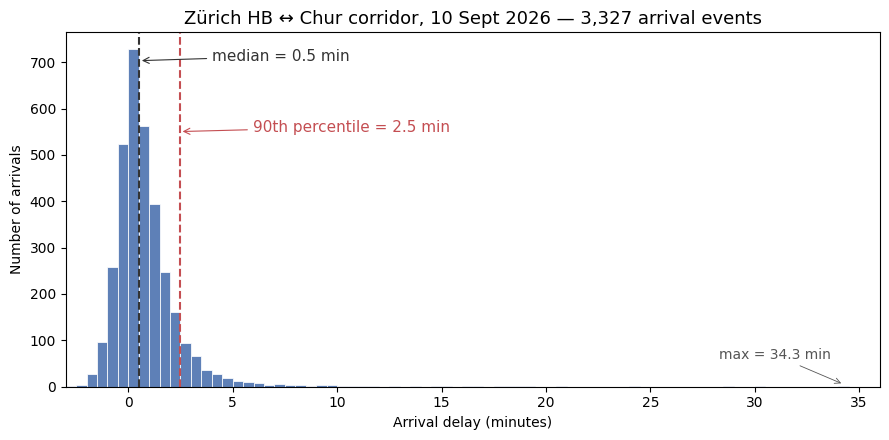

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.5))

delays = corr['arr_delay_min']

# Full range, no clipping
xmin, xmax = -3, 36
ax.hist(
    delays,
    bins=np.arange(xmin, xmax + 0.5, 0.5),
    color='#4C72B0',
    edgecolor='white',
    linewidth=0.6,
    alpha=0.9,
)

median = delays.median()
p90 = delays.quantile(0.90)
p99 = delays.quantile(0.99)

ax.axvline(median, linestyle='--', color='#333', linewidth=1.5)
ax.axvline(p90, linestyle='--', color='#C44E52', linewidth=1.5)

ax.annotate(
    f'median = {median:.1f} min',
    xy=(median, ax.get_ylim()[1] * 0.92),
    xytext=(median + 3.5, ax.get_ylim()[1] * 0.92),
    fontsize=11, color='#333',
    arrowprops=dict(arrowstyle='->', color='#333', lw=0.8),
)
ax.annotate(
    f'90th percentile = {p90:.1f} min',
    xy=(p90, ax.get_ylim()[1] * 0.72),
    xytext=(p90 + 3.5, ax.get_ylim()[1] * 0.72),
    fontsize=11, color='#C44E52',
    arrowprops=dict(arrowstyle='->', color='#C44E52', lw=0.8),
)

# Mark the max as a small label, not a clipped bin
ax.annotate(
    f'max = {delays.max():.1f} min',
    xy=(delays.max(), 5),
    xytext=(delays.max() - 6, 60),
    fontsize=10, color='#555',
    arrowprops=dict(arrowstyle='->', color='#555', lw=0.6),
)

ax.set_xlim(xmin, xmax)
ax.set_xlabel('Arrival delay (minutes)')
ax.set_ylabel('Number of arrivals')
ax.set_title(f'Zürich HB ↔ Chur corridor, 10 Sept 2026 — {len(delays):,} arrival events',
             fontsize=13)

plt.tight_layout()
plt.savefig('plot1_delay_distribution.png', bbox_inches='tight', facecolor='white', dpi=200)
plt.show()

## 5. Per-segment propagation regressions ($\beta$ and $\alpha$)

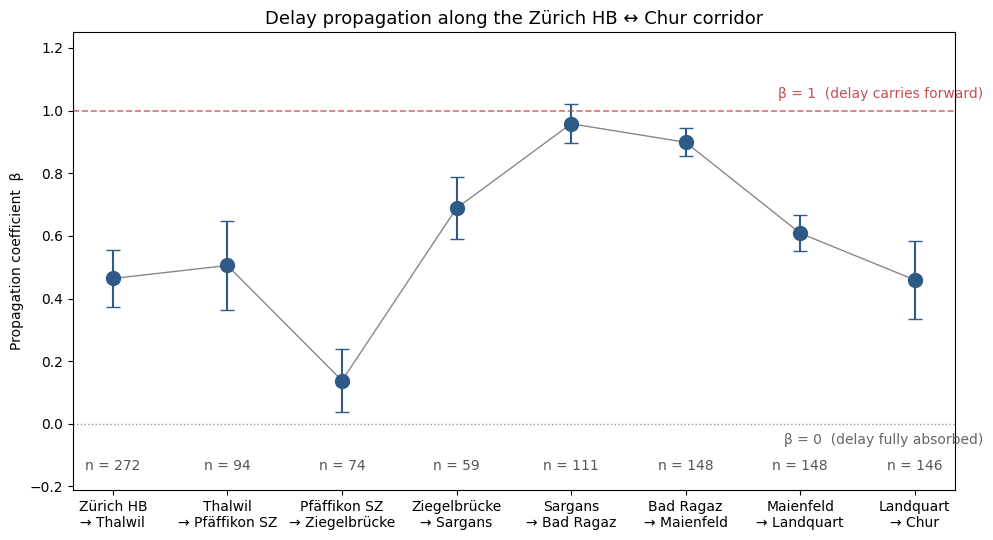

In [ ]:
# ---- Plot 2: propagation coefficient along the corridor ----

# Build a small display-friendly frame for the plot
plot_df = results.copy()
plot_df['segment_short'] = [
    'Zürich HB\n→ Thalwil',
    'Thalwil\n→ Pfäffikon SZ',
    'Pfäffikon SZ\n→ Ziegelbrücke',
    'Ziegelbrücke\n→ Sargans',
    'Sargans\n→ Bad Ragaz',
    'Bad Ragaz\n→ Maienfeld',
    'Maienfeld\n→ Landquart',
    'Landquart\n→ Chur',
]

# recompute SE_beta so we can plot 95% CI
# (we already have this in the results table from linregress, but let's make sure)
se_by_segment = []
for k in range(len(corridor_names_ordered) - 1):
    a, b = corridor_names_ordered[k], corridor_names_ordered[k+1]
    pair = delay_matrix[[a, b]].dropna()
    res = stats.linregress(pair[a].values, pair[b].values)
    se_by_segment.append(res.stderr)
plot_df['se_beta'] = se_by_segment
plot_df['ci95'] = 1.96 * plot_df['se_beta']

fig, ax = plt.subplots(figsize=(10, 5.5))

x = np.arange(len(plot_df))
y = plot_df['beta_all'].values
yerr = plot_df['ci95'].values

# Connect points with a thin light line, then overlay dots with errorbars
ax.plot(x, y, color='#888', linewidth=1, zorder=1)
ax.errorbar(
    x, y, yerr=yerr,
    fmt='o', markersize=10,
    color='#2E5A88',
    ecolor='#2E5A88', elinewidth=1.5, capsize=5,
    zorder=2,
)

# Reference lines
ax.axhline(1.0, linestyle='--', color='#C44E52', linewidth=1.2, alpha=0.8)
ax.text(len(plot_df) - 0.4, 1.03, 'β = 1  (delay carries forward)',
        color='#C44E52', fontsize=10, ha='right', va='bottom')

ax.axhline(0.0, linestyle=':', color='#999', linewidth=1)
ax.text(len(plot_df) - 0.4, -0.03, 'β = 0  (delay fully absorbed)',
        color='#666', fontsize=10, ha='right', va='top')

# n= labels under each point
ymin_pos = min(y - yerr) - 0.15
for i, n in enumerate(plot_df['n_all']):
    ax.text(i, ymin_pos, f'n = {n}', ha='center', va='top',
            fontsize=10, color='#555')

# Axes
ax.set_xticks(x)
ax.set_xticklabels(plot_df['segment_short'], fontsize=10)
ax.set_ylabel('Propagation coefficient  β')
ax.set_title('Delay propagation along the Zürich HB ↔ Chur corridor',fontsize=13)

ax.set_ylim(ymin_pos - 0.1, 1.25)

plt.tight_layout()
plt.savefig('plot2_propagation_beta.png', bbox_inches='tight', facecolor='white', dpi=200)
plt.show()

## 6. Residual diagnostics

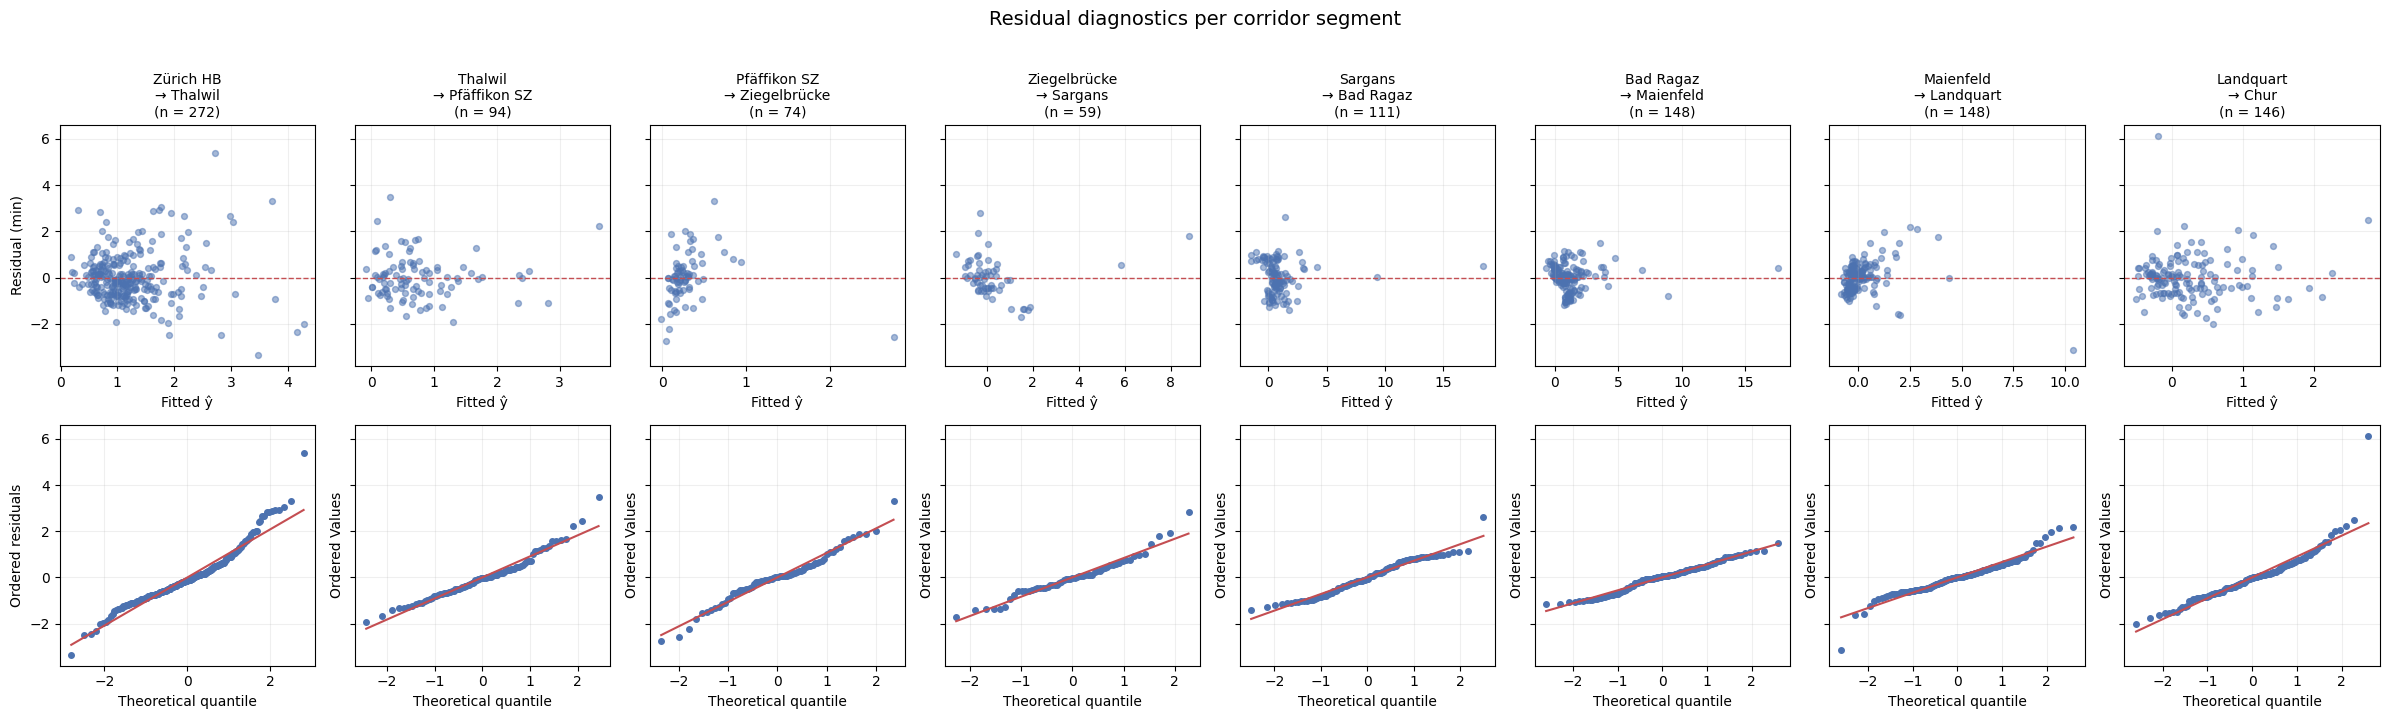

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Build a figure with two rows: residuals-vs-fitted (top) and Q-Q plots (bottom)
# and 8 columns: one per segment

fig, axes = plt.subplots(2, 8, figsize=(24, 7), sharey='row')

for k in range(len(corridor_names_ordered) - 1):
    a = corridor_names_ordered[k]
    b = corridor_names_ordered[k + 1]

    pair = delay_matrix[[a, b]].dropna()
    x = pair[a].values
    y = pair[b].values

    if len(x) < 5:
        continue

    # Fit OLS
    result = stats.linregress(x, y)
    y_hat = result.intercept + result.slope * x
    residuals = y - y_hat

    # --- Top row: residuals vs fitted values ---
    ax_top = axes[0, k]
    ax_top.scatter(y_hat, residuals, s=18, alpha=0.5, color='#4C72B0')
    ax_top.axhline(0, color='#C44E52', linewidth=1, linestyle='--')
    ax_top.set_title(f"{a}\n→ {b}\n(n = {len(x)})", fontsize=10)
    if k == 0:
        ax_top.set_ylabel("Residual (min)")
    ax_top.set_xlabel("Fitted ŷ")
    ax_top.grid(True, alpha=0.2)

    # --- Bottom row: Q-Q plot against normal ---
    ax_bot = axes[1, k]
    stats.probplot(residuals, dist='norm', plot=ax_bot)
    # The default probplot title is annoying; clear it
    ax_bot.set_title("")
    ax_bot.get_lines()[0].set_markerfacecolor('#4C72B0')
    ax_bot.get_lines()[0].set_markeredgecolor('#4C72B0')
    ax_bot.get_lines()[0].set_markersize(4)
    ax_bot.get_lines()[1].set_color('#C44E52')
    if k == 0:
        ax_bot.set_ylabel("Ordered residuals")
    ax_bot.set_xlabel("Theoretical quantile")
    ax_bot.grid(True, alpha=0.2)

plt.suptitle("Residual diagnostics per corridor segment", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('residual_diagnostics.png', bbox_inches='tight', facecolor='white', dpi=180)
plt.show()

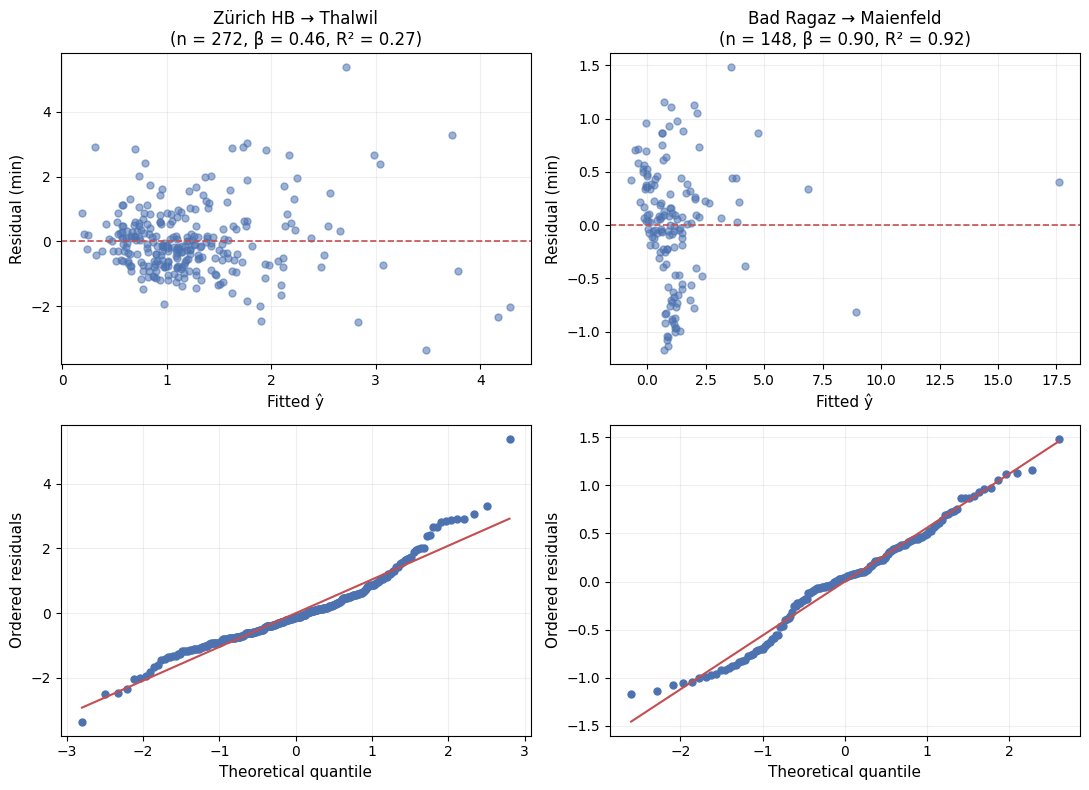

In [ ]:
# Two-segment version, sized for a 16:9 slide
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

segments_to_show = [
    (0, 'Zürich HB → Thalwil'),         # absorbing, low R², high variability
    (5, 'Bad Ragaz → Maienfeld'),       # carrier, high R², tight residuals
]

for col, (k, label) in enumerate(segments_to_show):
    a = corridor_names_ordered[k]
    b = corridor_names_ordered[k + 1]

    pair = delay_matrix[[a, b]].dropna()
    x = pair[a].values
    y = pair[b].values

    result = stats.linregress(x, y)
    y_hat = result.intercept + result.slope * x
    residuals = y - y_hat

    # Top: residuals vs fitted
    ax_top = axes[0, col]
    ax_top.scatter(y_hat, residuals, s=25, alpha=0.55, color='#4C72B0')
    ax_top.axhline(0, color='#C44E52', linewidth=1.2, linestyle='--')
    ax_top.set_title(f"{label}\n(n = {len(x)}, β = {result.slope:.2f}, R² = {result.rvalue**2:.2f})",
                     fontsize=12)
    ax_top.set_ylabel("Residual (min)", fontsize=11)
    ax_top.set_xlabel("Fitted ŷ", fontsize=11)
    ax_top.grid(True, alpha=0.2)

    # Bottom: Q-Q vs normal
    ax_bot = axes[1, col]
    stats.probplot(residuals, dist='norm', plot=ax_bot)
    ax_bot.set_title("")
    ax_bot.get_lines()[0].set_markerfacecolor('#4C72B0')
    ax_bot.get_lines()[0].set_markeredgecolor('#4C72B0')
    ax_bot.get_lines()[0].set_markersize(5)
    ax_bot.get_lines()[1].set_color('#C44E52')
    ax_bot.set_ylabel("Ordered residuals", fontsize=11)
    ax_bot.set_xlabel("Theoretical quantile", fontsize=11)
    ax_bot.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('residual_diagnostics_slide.png', bbox_inches='tight', facecolor='white', dpi=200)
plt.show()